In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 796.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.4 MB/s eta 0:00:00


Using device: cpu


Extracting qm9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Train size: 100000
Validation size: 10000
Test size: 20831

Training Mean: 0.32204368710517883
Training Std: 1.274855375289917


/tmp/ipykernel_3290/972209324.py:73: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  train_y = train_dataset.data.y[:, target]
/tmp/ipykernel_3290/972209324.py:84: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress 


Epoch 1
Train Loss: 0.095954
Val RMSE: 0.300989
Val MAE: 0.235295
Val R²: 0.854061
Best model saved.

Epoch 2
Train Loss: 0.044422
Val RMSE: 0.222773
Val MAE: 0.168497
Val R²: 0.920054
Best model saved.

Epoch 3
Train Loss: 0.038140
Val RMSE: 0.215094
Val MAE: 0.165283
Val R²: 0.925471
Best model saved.

Epoch 4
Train Loss: 0.032707
Val RMSE: 0.235243
Val MAE: 0.179604
Val R²: 0.910854

Epoch 5
Train Loss: 0.030245
Val RMSE: 0.213367
Val MAE: 0.160720
Val R²: 0.926662
Best model saved.

Epoch 6
Train Loss: 0.028115
Val RMSE: 0.161766
Val MAE: 0.123386
Val R²: 0.957846
Best model saved.

Epoch 7
Train Loss: 0.026165
Val RMSE: 0.170791
Val MAE: 0.129736
Val R²: 0.953010

Epoch 8
Train Loss: 0.025029
Val RMSE: 0.173267
Val MAE: 0.129396
Val R²: 0.951638

Epoch 9
Train Loss: 0.023625
Val RMSE: 0.172512
Val MAE: 0.133046
Val R²: 0.952059

Epoch 10
Train Loss: 0.022280
Val RMSE: 0.210314
Val MAE: 0.157401
Val R²: 0.928746

Epoch 11
Train Loss: 0.021577
Val RMSE: 0.150326
Val MAE: 0.114667
V

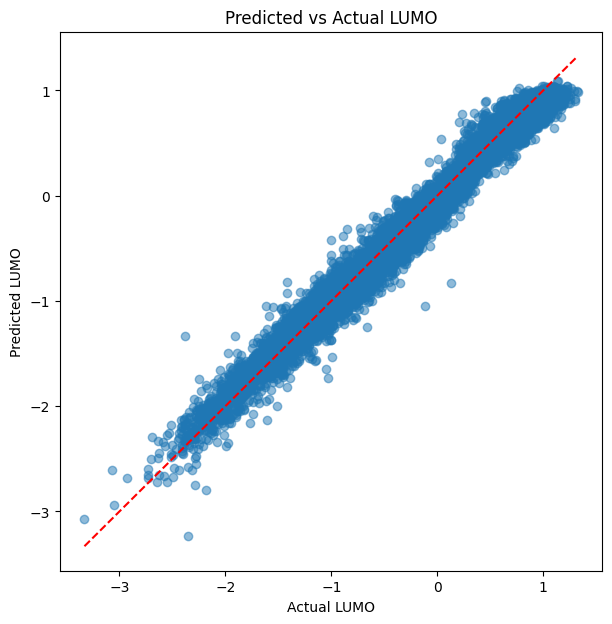

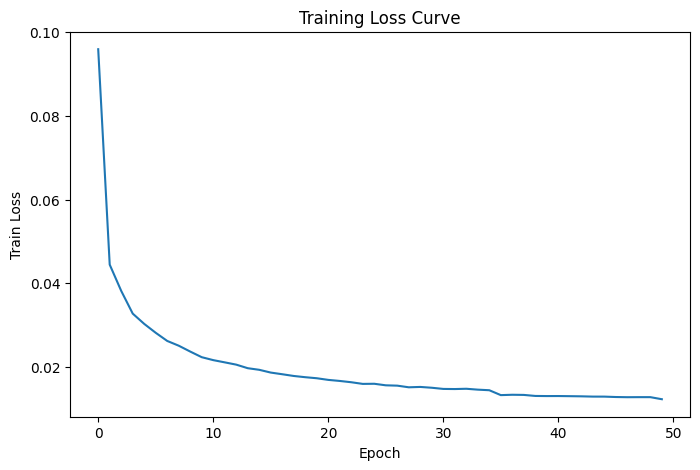


SAMPLE PREDICTIONS
Actual: -0.881052 | Predicted: -0.928525
Actual: -1.063549 | Predicted: -1.035584
Actual: 0.048175 | Predicted: 0.015670
Actual: 0.280900 | Predicted: 0.420972
Actual: -2.034633 | Predicted: -2.115597
Actual: -0.991555 | Predicted: -0.918811
Actual: 0.734631 | Predicted: 0.698264
Actual: -2.436461 | Predicted: -2.605246
Actual: -0.264916 | Predicted: -0.199208
Actual: 0.344523 | Predicted: 0.367920


In [ ]:

# LUMO PROPERTY PREDICTION USING GIN

import os
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch.nn import Linear, Sequential, ReLU, BatchNorm1d, Dropout
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt


# REPRODUCIBILITY


seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


# LOAD DATASET


path = "./qm9"
dataset = QM9(path)

# LUMO TARGET INDEX
# QM9 target index for LUMO = 3
target = 3


# SHUFFLE DATASET


dataset = dataset.shuffle()


# TRAIN / VAL / TEST SPLIT


train_dataset = dataset[:100000]
val_dataset = dataset[100000:110000]
test_dataset = dataset[110000:]

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


# NORMALIZATION (ONLY USING TRAIN DATA)


train_y = train_dataset.data.y[:, target]

mean = train_y.mean().item()
std = train_y.std().item()

print(f"\nTraining Mean: {mean}")
print(f"Training Std: {std}")

# Normalize datasets
for split in [train_dataset, val_dataset, test_dataset]:
    split.data.y[:, target] = (
        split.data.y[:, target] - mean
    ) / std


# DATALOADERS


batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# GIN MODEL


class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64


        # GIN Layer 1


        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)


        # GIN Layer 2


        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)


        # GIN Layer 3


        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)


        # REGRESSION HEAD


        self.lin1 = Linear(hidden_dim, 64)
        self.dropout = Dropout(0.2)
        self.lin2 = Linear(64, 1)

    def forward(self, data):

        x = data.x.float()
        edge_index = data.edge_index
        batch = data.batch


        # GIN Layers


        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)


        # GLOBAL POOLING


        x = global_add_pool(x, batch)


        # REGRESSION HEAD


        x = self.lin1(x)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.squeeze()


# MODEL INITIALIZATION


model = GINNet(dataset.num_features).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

criterion = torch.nn.MSELoss()


# TRAIN FUNCTION


def train():

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        pred = model(data)

        target_y = data.y[:, target]

        loss = criterion(pred, target_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)


# EVALUATION FUNCTION


def evaluate(loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            pred = model(data)

            preds.append(pred.cpu())
            targets.append(data.y[:, target].cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()


    # INVERSE NORMALIZATION


    preds_denorm = preds * std + mean
    targets_denorm = targets * std + mean

    rmse = np.sqrt(
        mean_squared_error(targets_denorm, preds_denorm)
    )

    mae = mean_absolute_error(
        targets_denorm,
        preds_denorm
    )

    r2 = r2_score(
        targets_denorm,
        preds_denorm
    )

    return rmse, mae, r2, preds_denorm, targets_denorm


# TRAINING LOOP


best_val_rmse = float("inf")

train_losses = []
val_rmses = []

epochs = 50

for epoch in range(1, epochs + 1):

    train_loss = train()

    val_rmse, val_mae, val_r2, _, _ = evaluate(val_loader)

    scheduler.step(val_rmse)

    train_losses.append(train_loss)
    val_rmses.append(val_rmse)

    print(f"\nEpoch {epoch}")

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val MAE: {val_mae:.6f}")
    print(f"Val R²: {val_r2:.6f}")


    # SAVE BEST MODEL


    if val_rmse < best_val_rmse:

        best_val_rmse = val_rmse

        torch.save(
            model.state_dict(),
            "best_lumo_model.pth"
        )

        print("Best model saved.")


# LOAD BEST MODEL


model.load_state_dict(
    torch.load("best_lumo_model.pth")
)


# FINAL TEST EVALUATION


test_rmse, test_mae, test_r2, preds, targets = evaluate(test_loader)

print("\n================================================")
print("FINAL TEST RESULTS")
print("================================================")

print(f"Test RMSE : {test_rmse:.6f}")
print(f"Test MAE  : {test_mae:.6f}")
print(f"Test R²   : {test_r2:.6f}")


# PREDICTED VS ACTUAL PLOT


plt.figure(figsize=(7, 7))

plt.scatter(
    targets,
    preds,
    alpha=0.5
)

min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual LUMO")
plt.ylabel("Predicted LUMO")

plt.title("Predicted vs Actual LUMO")

plt.show()


# LOSS CURVE


plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")

plt.title("Training Loss Curve")

plt.show()


# SAMPLE PREDICTIONS


print("\n================================================")
print("SAMPLE PREDICTIONS")
print("================================================")

for i in range(10):

    print(
        f"Actual: {targets[i]:.6f} | "
        f"Predicted: {preds[i]:.6f}"
    )

In [ ]:
import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from torch.nn import (
    Linear,
    Sequential,
    ReLU,
    BatchNorm1d,
    Dropout
)

from torch_geometric.nn import (
    GINConv,
    global_add_pool
)



Embedding Shape: (20831, 64)


PermutationExplainer explainer: 301it [00:16, 12.35it/s]                         
/tmp/ipykernel_3290/3208743806.py:226: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


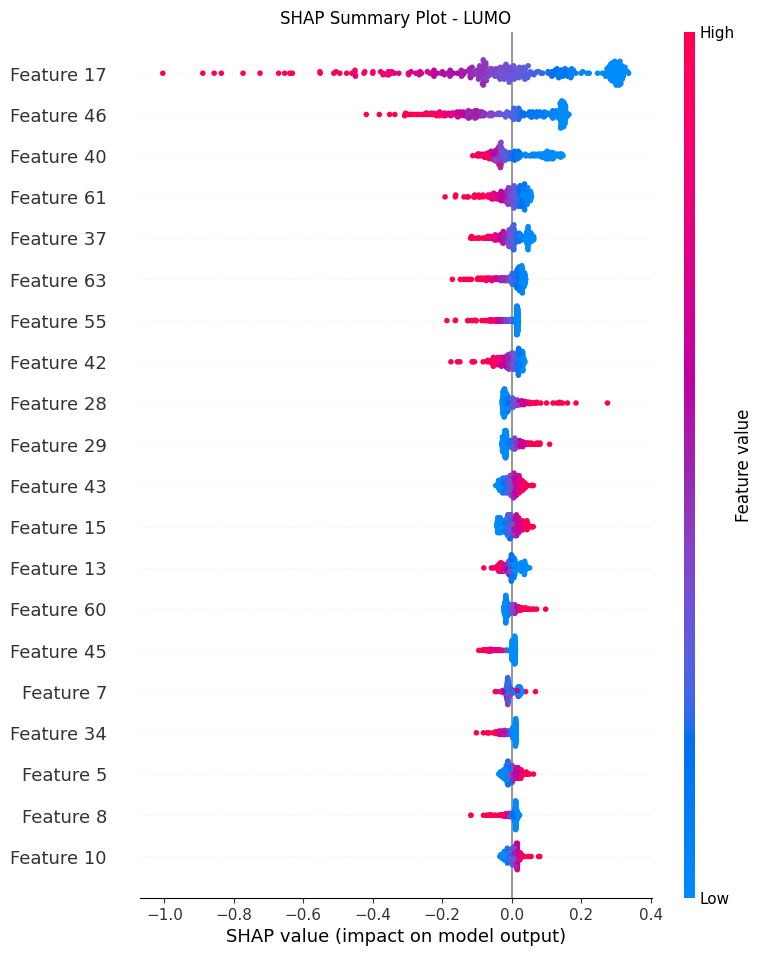

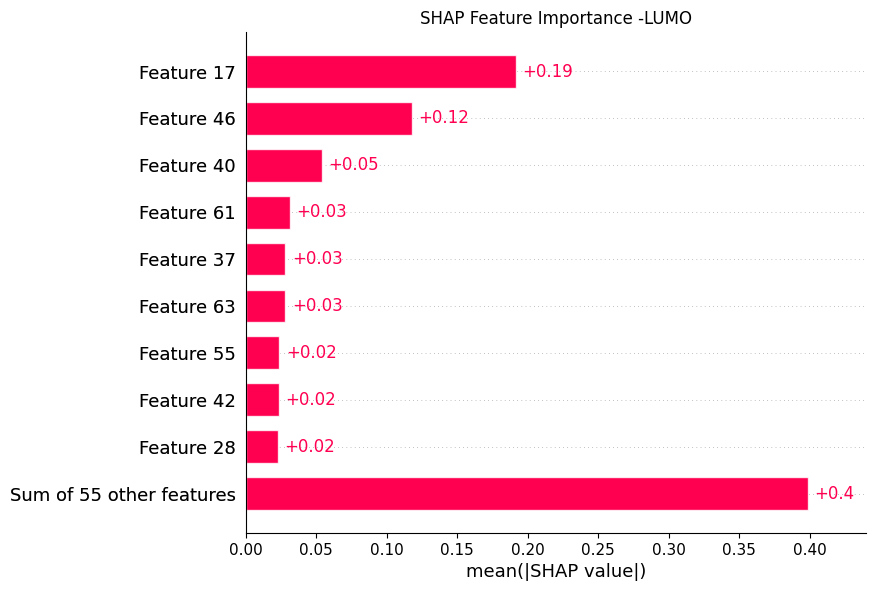


TOP IMPORTANT EMBEDDING FEATURES
    Embedding Dimension  Mean SHAP Value
17                   17         0.191609
46                   46         0.117587
40                   40         0.053761
61                   61         0.031117
37                   37         0.028130
63                   63         0.028105
55                   55         0.023715
42                   42         0.023620
28                   28         0.022974
29                   29         0.019734


In [ ]:

# SHAP ANALYSIS FOR GIN MODEL
# (Graph Embedding Explainability)


import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# MODIFY MODEL TO RETURN EMBEDDINGS


class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64


        # GIN Layer 1


        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)


        # GIN Layer 2


        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)


        # GIN Layer 3


        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)


        # REGRESSION HEAD


        self.lin1 = Linear(hidden_dim, 64)

        self.dropout = Dropout(0.2)

        self.lin2 = Linear(64, 1)


    # NEW: return_embedding flag


    def forward(self, data, return_embedding=False):

        x = data.x.float()

        edge_index = data.edge_index

        batch = data.batch


        # GIN layers


        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)


        # GRAPH EMBEDDING


        embedding = global_add_pool(x, batch)


        # Regression Head


        out = self.lin1(embedding)

        out = F.relu(out)

        out = self.dropout(out)

        out = self.lin2(out)

        if return_embedding:
            return out.squeeze(), embedding

        return out.squeeze()


# RELOAD TRAINED MODEL


model = GINNet(dataset.num_features).to(device)

model.load_state_dict(
    torch.load("best_lumo_model.pth")
)

model.eval()


# EXTRACT EMBEDDINGS


embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(emb.cpu().numpy())

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)

y_targets = np.concatenate(targets, axis=0)

print("Embedding Shape:", X_embeddings.shape)


# CREATE REGRESSION HEAD WRAPPER


class RegressionHead(torch.nn.Module):

    def __init__(self, lin1, dropout, lin2):

        super().__init__()

        self.lin1 = lin1
        self.dropout = dropout
        self.lin2 = lin2

    def forward(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        x = self.lin1(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.detach().cpu().numpy()


# SHAP EXPLAINER


reg_head = RegressionHead(
    model.lin1,
    model.dropout,
    model.lin2
)

# Smaller subset for speed
background = X_embeddings[:200]

sample_data = X_embeddings[200:500]

explainer = shap.Explainer(
    reg_head,
    background
)

shap_values = explainer(sample_data)


# SHAP SUMMARY PLOT


plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP Summary Plot - LUMO")

plt.show()


# SHAP BAR PLOT


plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_values,
    show=False
)

plt.title("SHAP Feature Importance -LUMO")

plt.show()


# FEATURE IMPORTANCE TABLE


mean_shap = np.abs(
    shap_values.values
).mean(axis=0)

feature_importance = pd.DataFrame({

    "Embedding Dimension":
    np.arange(len(mean_shap)),

    "Mean SHAP Value":
    mean_shap

})

feature_importance = feature_importance.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

print("\n================================================")
print("TOP IMPORTANT EMBEDDING FEATURES")
print("================================================")

print(feature_importance.head(10))

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dee7a2e767abef5383506a4c0fb0898e2d056416f523ec7253923ff74a0d9070
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

Embedding shape: (20831, 64)
Actual LUMO: -1.2443713
Predicted LUMO: -1.2789809


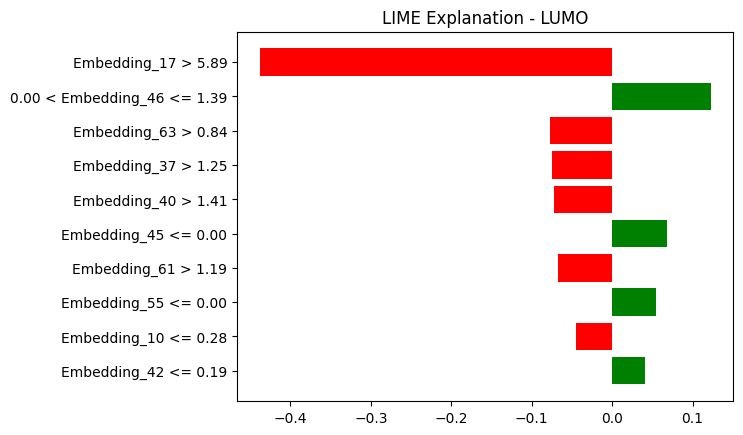


Top LIME Features:
Embedding_17 > 5.89 : -0.43826178091335954
0.00 < Embedding_46 <= 1.39 : 0.12244125936159789
Embedding_63 > 0.84 : -0.07746165384980375
Embedding_37 > 1.25 : -0.07445700131951488
Embedding_40 > 1.41 : -0.07246631027699793
Embedding_45 <= 0.00 : 0.06810025547010545
Embedding_61 > 1.19 : -0.06675699621064386
Embedding_55 <= 0.00 : 0.054073118334350655
Embedding_10 <= 0.28 : -0.04472736190869619
Embedding_42 <= 0.19 : 0.04080467117507796


In [ ]:

# LIME FOR GNN EMBEDDING INTERPRETATION


import lime
import lime.lime_tabular
import numpy as np
import torch
import torch.nn.functional as F


# EXTRACT TEST EMBEDDINGS


model.eval()

embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(
            emb.cpu().numpy()
        )

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)
y_targets = np.concatenate(targets, axis=0)

print("Embedding shape:", X_embeddings.shape)


# REGRESSION HEAD WRAPPER (NO DROPOUT)


class RegressionHead:

    def __init__(self, lin1, lin2):

        self.lin1 = lin1
        self.lin2 = lin2

    def predict(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():

            x = self.lin1(x)

            x = F.relu(x)

            x = self.lin2(x)

        return x.cpu().numpy()

reg_head = RegressionHead(
    model.lin1,
    model.lin2
)


# CREATE LIME EXPLAINER


feature_names = [
    f"Embedding_{i}"
    for i in range(X_embeddings.shape[1])
]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_embeddings,
    feature_names=feature_names,
    mode='regression'
)


# PICK ONE TEST MOLECULE


sample_index = 10

sample = X_embeddings[sample_index]

actual_normalized = y_targets[sample_index]

actual_denorm = actual_normalized * std + mean

print("Actual LUMO:", actual_denorm)

prediction = reg_head.predict(
    sample.reshape(1, -1)
)

pred_denorm = prediction[0][0] * std + mean

print("Predicted LUMO:", pred_denorm)


# GENERATE LIME EXPLANATION


exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=reg_head.predict,
    num_features=10
)


# SHOW RESULTS


fig = exp.as_pyplot_figure()

plt.title("LIME Explanation - LUMO")

plt.show()


# PRINT FEATURE CONTRIBUTIONS


print("\nTop LIME Features:")

for feature, weight in exp.as_list():
    print(feature, ":", weight)